# 数据处理

In [45]:
import pandas as pd
import numpy as np

In [46]:
data = pd.read_csv(r"..\data\china_flu_weekly.csv")
data_val = pd.read_csv(r"..\data\validation_set_2023_2024.csv")

In [47]:
data.head()

,iso_year,iso_week,week_start,spec_processed,h3n2_positive,inf_all,inf_a,inf_b,h3n2_pct,inf_pct,ili_activity,ili_pct
0,2005,39,2005/9/26,337.0,6.0,38.0,29.0,9.0,0.0178,0.1128,1.0,NaN
1,2005,40,2005/10/3,261.0,0.0,13.0,13.0,0.0,0.0000,0.0498,1.0,NaN
2,2005,41,2005/10/10,544.0,3.0,46.0,43.0,3.0,0.0055,0.0846,1.0,NaN
3,2005,42,2005/10/17,849.0,3.0,106.0,64.0,42.0,0.0035,0.1249,1.0,NaN
4,2005,43,2005/10/24,1086.0,5.0,124.0,113.0,11.0,0.0046,0.1142,1.0,NaN


In [48]:
data_has_ili = data[data['ili_pct'].notnull()]
data_has_ili

,iso_year,iso_week,week_start,spec_processed,h3n2_positive,inf_all,inf_a,inf_b,h3n2_pct,inf_pct,ili_activity,ili_pct
969,2025,45,2025/11/3,28242.0,6773.0,6986.0,6897.0,89.0,0.2398,0.2474,4.0,6.1
970,2025,46,2025/11/10,28026.0,9024.0,9176.0,9096.0,80.0,0.3220,0.3274,4.0,7.0
971,2025,47,2025/11/17,28504.0,11478.0,11586.0,11515.0,71.0,0.4027,0.4065,4.0,8.6
972,2025,48,2025/11/24,28656.0,13631.0,13752.0,13706.0,46.0,0.4757,0.4799,4.0,9.1
973,2025,49,2025/12/1,28963.0,14530.0,14624.0,14568.0,56.0,0.5017,0.5049,4.0,7.9
974,2025,50,2025/12/8,25364.0,11792.0,11848.0,11804.0,44.0,0.4649,0.4671,4.0,6.3
975,2025,51,2025/12/15,27098.0,10920.0,11014.0,10936.0,78.0,0.4030,0.4065,3.0,4.9
976,2025,52,2025/12/22,26369.0,8542.0,8661.0,8552.0,109.0,0.3239,0.3285,3.0,4.2
977,2026,1,2025/12/29,25314.0,6770.0,6929.0,6778.0,151.0,0.2674,0.2737,2.0,4.1
978,2026,2,2026/1/5,25983.0,5758.0,6000.0,5777.0,223.0,0.2216,0.2309,2.0,3.7


In [49]:
data_h3n2_pct = pd.concat([
    data_val['h3n2_pct'],
    data_has_ili['h3n2_pct']
], ignore_index=True)

data_ili_pct = pd.concat([
    data_val['ili_pct_full'],
    data_has_ili['ili_pct'].rename('ili_pct_full')
], ignore_index=True)

In [50]:
# 对 data_h3n2_pct (x) 和 data_ili_pct (y) 做一元线性回归
reg_df = pd.concat([data_h3n2_pct, data_ili_pct], axis=1).dropna()
x = reg_df["h3n2_pct"].values
y = reg_df["ili_pct_full"].values

# y = kx + b
k, b = np.polyfit(x, y, 1)

print(f"线性回归函数: ili_pct = {k:.6f} * h3n2_pct + {b:.6f}")

# 可选：计算R^2
y_pred = k * x + b
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"R^2 = {r2:.4f}")

线性回归函数: ili_pct = 7.977024 * h3n2_pct + 4.140579
R^2 = 0.4246


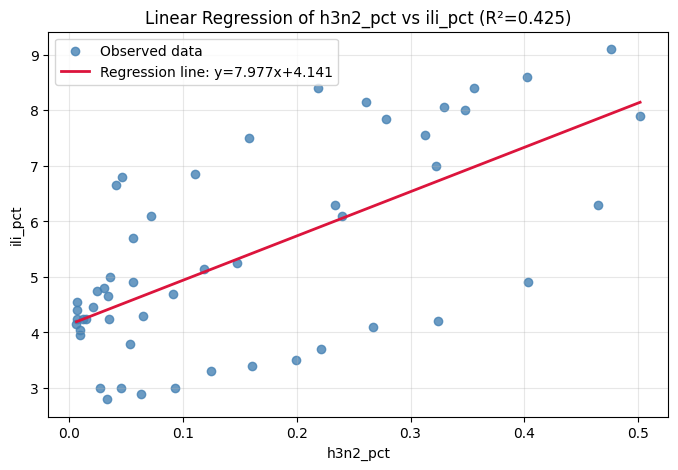

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="steelblue", alpha=0.8, label="Observed data")

x_line = np.linspace(x.min(), x.max(), 200)
y_line = k * x_line + b
plt.plot(
    x_line, y_line, color="crimson", linewidth=2,
    label=f"Regression line: y={k:.3f}x+{b:.3f}"
)

plt.xlabel("h3n2_pct")
plt.ylabel("ili_pct")
plt.title(f"Linear Regression of h3n2_pct vs ili_pct (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
mask = data['ili_pct'].isnull()
data.loc[mask, 'ili_pct'] = k * data.loc[mask, 'h3n2_pct'] + b
data.head()

,iso_year,iso_week,week_start,spec_processed,h3n2_positive,inf_all,inf_a,inf_b,h3n2_pct,inf_pct,ili_activity,ili_pct
0,2005,39,2005/9/26,337.0,6.0,38.0,29.0,9.0,0.0178,0.1128,1.0,4.282570
1,2005,40,2005/10/3,261.0,0.0,13.0,13.0,0.0,0.0000,0.0498,1.0,4.140579
2,2005,41,2005/10/10,544.0,3.0,46.0,43.0,3.0,0.0055,0.0846,1.0,4.184452
3,2005,42,2005/10/17,849.0,3.0,106.0,64.0,42.0,0.0035,0.1249,1.0,4.168498
4,2005,43,2005/10/24,1086.0,5.0,124.0,113.0,11.0,0.0046,0.1142,1.0,4.177273


In [54]:
# 获取h3n2流行强度
data['I_obs']=data['ili_pct']*data['h3n2_pct']
data

,iso_year,iso_week,week_start,spec_processed,h3n2_positive,inf_all,inf_a,inf_b,h3n2_pct,inf_pct,ili_activity,ili_pct,I_obs
0,2005,39,2005/9/26,337.0,6.0,38.0,29.0,9.0,0.0178,0.1128,1.0,4.282570,0.076230
1,2005,40,2005/10/3,261.0,0.0,13.0,13.0,0.0,0.0000,0.0498,1.0,4.140579,0.000000
2,2005,41,2005/10/10,544.0,3.0,46.0,43.0,3.0,0.0055,0.0846,1.0,4.184452,0.023014
3,2005,42,2005/10/17,849.0,3.0,106.0,64.0,42.0,0.0035,0.1249,1.0,4.168498,0.014590
4,2005,43,2005/10/24,1086.0,5.0,124.0,113.0,11.0,0.0046,0.1142,1.0,4.177273,0.019215
...,...,...,...,...,...,...,...,...,...,...,...,...,...
984,2026,8,2026/2/16,21821.0,1233.0,2041.0,1240.0,801.0,0.0565,0.0935,2.0,4.900000,0.276850
985,2026,9,2026/2/23,25358.0,1150.0,2396.0,1160.0,1236.0,0.0454,0.0945,2.0,3.000000,0.136200
986,2026,10,2026/3/2,25305.0,850.0,2134.0,863.0,1271.0,0.0336,0.0843,2.0,2.800000,0.094080
987,2026,11,2026/3/9,26081.0,716.0,2399.0,748.0,1651.0,0.0275,0.0920,2.0,3.000000,0.082500
